C:\Users\anunn\AppData\Local\Temp\ipykernel_964\1637318563.py:15: RuntimeWarning: invalid value encountered in sqrt
  sqrt_term = np.sqrt(b**4 - (a**4 * np.sin(2 * theta)**2))


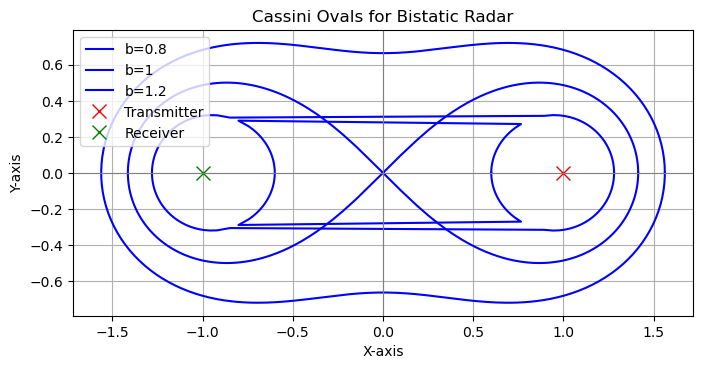

In [1]:
import numpy as np
import matplotlib.pyplot as plt

def plot_cassini_oval(a, b, ax):
    """
    Plots a Cassini oval given parameters 'a' and 'b'.
    'a' is half the distance between the foci.
    'b' is a constant related to the product of distances.
    'ax' is the matplotlib axes object to plot on.
    """
    theta = np.linspace(0, 2 * np.pi, 500)
    
    # Calculate r^2 values
    r_squared_term = a**2 * np.cos(2 * theta)
    sqrt_term = np.sqrt(b**4 - (a**4 * np.sin(2 * theta)**2))

    # Handle cases where the square root term might be imaginary
    # (i.e., when b^4 < a^4 * sin^2(2*theta))
    # This indicates regions where no real solution for r exists,
    # leading to the "peanut" shape breaking into two ovals.
    valid_indices = ~np.isnan(sqrt_term)

    r_squared_plus = r_squared_term[valid_indices] + sqrt_term[valid_indices]
    r_squared_minus = r_squared_term[valid_indices] - sqrt_term[valid_indices]
    
    # Take the square root to get r, considering positive and negative roots
    # and ensuring r is real and positive
    r_plus = np.sqrt(r_squared_plus[r_squared_plus >= 0])
    r_minus = np.sqrt(r_squared_minus[r_squared_minus >= 0])

    # Convert to Cartesian coordinates
    x_plus = r_plus * np.cos(theta[valid_indices][r_squared_plus >= 0])
    y_plus = r_plus * np.sin(theta[valid_indices][r_squared_plus >= 0])
    
    x_minus = r_minus * np.cos(theta[valid_indices][r_squared_minus >= 0])
    y_minus = r_minus * np.sin(theta[valid_indices][r_squared_minus >= 0])

    ax.plot(x_plus, y_plus, color='blue', label=f'b={b}')
    ax.plot(x_minus, y_minus, color='blue') # Plot the inner part if it exists

# Example usage:
fig, ax = plt.subplots(figsize=(8, 8))

# Define 'a' (half the distance between foci)
a_val = 1

# Plot ovals with different 'b' values
plot_cassini_oval(a_val, 0.8 * a_val, ax) # Two separate ovals
plot_cassini_oval(a_val, a_val, ax)     # Lemniscate of Bernoulli
plot_cassini_oval(a_val, 1.2 * a_val, ax) # Single oval

# Plot foci (transmitter and receiver)
ax.plot(a_val, 0, 'rx', markersize=10, label='Transmitter')
ax.plot(-a_val, 0, 'gx', markersize=10, label='Receiver')

ax.set_title('Cassini Ovals for Bistatic Radar')
ax.set_xlabel('X-axis')
ax.set_ylabel('Y-axis')
ax.axhline(0, color='grey', linewidth=0.8)
ax.axvline(0, color='grey', linewidth=0.8)
ax.set_aspect('equal', adjustable='box')
ax.legend()
ax.grid(True)
plt.show()